# 06 — Method Comparison

## Executive Summary
Head-to-head evaluation of all cloud fraction estimation methods:

| Method | Notebook | Output CSV |
|--------|----------|------------|
| R/B ratio threshold | `02_rb_threshold` | `cf_rb_threshold.csv` |
| ResNet-34 U-Net CNN | `03_cnn_segmentation` | `cf_cnn.csv` |
| MobileNetV2 U-Net | `03b_simpler_models` | `cf_mobilenet.csv` |
| Random Forest | `03b_simpler_models` | `cf_rf.csv` |

Gemma VLM (notebook 04) is excluded — too slow for routine use (~10 min/image on CPU).

**Analyses:**
1. Pairwise scatter plots and metrics (MAE, RMSE, Pearson r)
2. Time series overlay
3. Monthly breakdown of disagreements
4. Flagged images — large spread between methods
5. Evaluation on Warsaw GT test set and ACS_WSI held-out set

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split as skl_split
from scipy import stats

from skycamera.config import CX, CY, R, CSV_DIR, PLOTS_DIR, FULL_RAW_DIR, CF_MAX_ZENITH_DEG, MODEL_DIR
from skycamera.io import load_image, load_acs_wsi_dataset, load_acs_wsi_pair
from skycamera.preprocessing import (
    build_circular_mask, build_zenith_weight_map, weighted_cf, _infer_dome_params,
)
from skycamera.threshold import cloud_fraction_rb_threshold

RAW_ROOT = FULL_RAW_DIR
ACS_ROOT = Path('D:/MOJE/DATA_SCIENCE/SKYCAMERA/ACS_WSI-v1.0.0')

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load a sample image just to get native resolution for dome mask
_sample = next(FULL_RAW_DIR.rglob('*.jpg'))
_s = load_image(_sample)
dome_mask      = build_circular_mask(_s.shape[0], _s.shape[1], CX, CY, R)
zenith_weights = build_zenith_weight_map(_s.shape[0], _s.shape[1], CX, CY, R, CF_MAX_ZENITH_DEG)
print(f'Setup complete  |  dome pixels: {dome_mask.sum():,}')
print(f'Image root: {RAW_ROOT}')

Setup complete  |  dome pixels: 2,762,359
Image root: D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\data\full_raw


## 1. Load results from all methods

Missing CSVs are skipped gracefully — run the corresponding notebook first.

In [2]:
dfs = {}
CSVS = {
    'R/B threshold':    CSV_DIR / 'cf_rb_threshold.csv',
    'ResNet-34 U-Net':  CSV_DIR / 'cf_cnn.csv',
    'MobileNetV2 U-Net': CSV_DIR / 'cf_mobilenet.csv',
    'Random Forest':    CSV_DIR / 'cf_rf.csv',
}

for name, path in CSVS.items():
    if path.exists():
        df = pd.read_csv(path, parse_dates=['timestamp'])
        dfs[name] = df
        print(f'{name:20s}: {len(df):,} rows  CF mean={df["cloud_fraction"].mean():.3f}')
    else:
        print(f'{name:20s}: NOT FOUND')

if len(dfs) < 2:
    print('\nNeed at least 2 methods — run notebooks 02, 03, 03b first.')

R/B threshold       : 9,276 rows  CF mean=0.633
ResNet-34 U-Net     : 16,585 rows  CF mean=0.626
MobileNetV2 U-Net   : 16,585 rows  CF mean=0.625
Random Forest       : NOT FOUND


## 2. Pairwise metrics

Each method pair is matched by timestamp (exact for R/B vs CNN;
date-level daily mean for comparisons involving the VLM which runs once per day).

In [3]:
def align_pair(df_a, df_b, name_a, name_b):
    """Align two CF DataFrames by timestamp or date."""
    a = df_a[['timestamp','cloud_fraction']].rename(columns={'cloud_fraction': name_a})
    b = df_b[['timestamp','cloud_fraction']].rename(columns={'cloud_fraction': name_b})

    # Try exact timestamp merge first
    merged = pd.merge(a, b, on='timestamp', how='inner')
    if len(merged) < 5:
        # Fall back to daily mean alignment
        a = a.copy(); b = b.copy()
        a['date'] = pd.to_datetime(a['timestamp']).dt.date
        b['date'] = pd.to_datetime(b['timestamp']).dt.date
        a_d = a.groupby('date')[name_a].mean().reset_index()
        b_d = b.groupby('date')[name_b].mean().reset_index()
        merged = pd.merge(a_d, b_d, on='date', how='inner')
    return merged


def pair_metrics(df, col_a, col_b):
    ok = df[col_a].notna() & df[col_b].notna()
    a, b = df.loc[ok, col_a].values, df.loc[ok, col_b].values
    mae  = float(np.mean(np.abs(a - b)))
    rmse = float(np.sqrt(np.mean((a - b)**2)))
    r    = float(np.corrcoef(a, b)[0, 1]) if len(a) > 2 else float('nan')
    return {'n': int(ok.sum()), 'MAE': round(mae,4), 'RMSE': round(rmse,4), 'r': round(r,4)}


names = list(dfs.keys())
metrics_rows = []
pairs = {}

for i in range(len(names)):
    for j in range(i+1, len(names)):
        na, nb = names[i], names[j]
        merged = align_pair(dfs[na], dfs[nb], na, nb)
        m = pair_metrics(merged, na, nb)
        metrics_rows.append({'Method A': na, 'Method B': nb, **m})
        pairs[(na, nb)] = merged
        print(f'{na} vs {nb}: n={m["n"]}  MAE={m["MAE"]:.4f}  RMSE={m["RMSE"]:.4f}  r={m["r"]:.4f}')

df_metrics = pd.DataFrame(metrics_rows)
df_metrics

R/B threshold vs ResNet-34 U-Net: n=9276  MAE=0.0641  RMSE=0.1419  r=0.9457
R/B threshold vs MobileNetV2 U-Net: n=9276  MAE=0.0835  RMSE=0.1718  r=0.9189
ResNet-34 U-Net vs MobileNetV2 U-Net: n=16585  MAE=0.0319  RMSE=0.0987  r=0.9755


,Method A,Method B,n,MAE,RMSE,r
0,R/B threshold,ResNet-34 U-Net,9276,0.0641,0.1419,0.9457
1,R/B threshold,MobileNetV2 U-Net,9276,0.0835,0.1718,0.9189
2,ResNet-34 U-Net,MobileNetV2 U-Net,16585,0.0319,0.0987,0.9755


## 3. Pairwise scatter plots

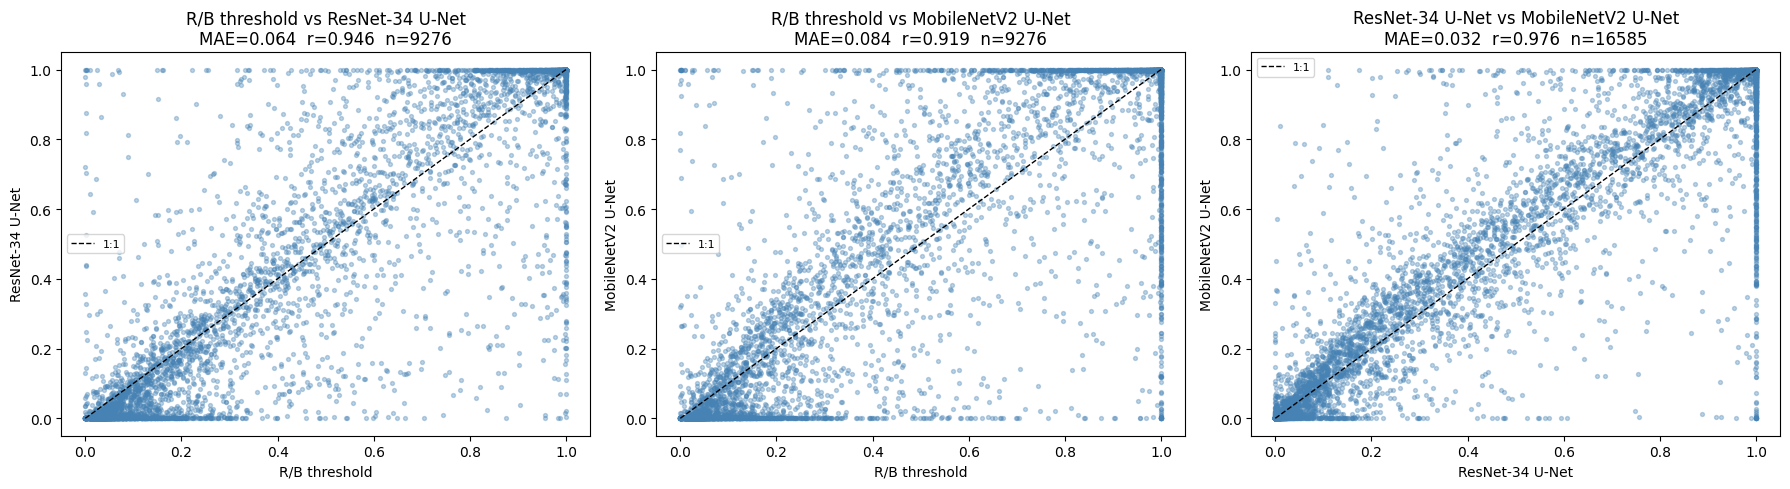

In [4]:
n_pairs = len(pairs)
if n_pairs == 0:
    print('No pairs to plot.')
else:
    fig, axes = plt.subplots(1, n_pairs, figsize=(6 * n_pairs, 5))
    if n_pairs == 1:
        axes = [axes]

    for ax, ((na, nb), merged) in zip(axes, pairs.items()):
        ok = merged[na].notna() & merged[nb].notna()
        ax.scatter(merged.loc[ok, na], merged.loc[ok, nb],
                   s=8, alpha=0.35, color='steelblue')
        ax.plot([0,1],[0,1],'k--', linewidth=1, label='1:1')
        m = pair_metrics(merged, na, nb)
        ax.set_xlabel(na); ax.set_ylabel(nb)
        ax.set_title(f'{na} vs {nb}\nMAE={m["MAE"]:.3f}  r={m["r"]:.3f}  n={m["n"]}')
        ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=8)

    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'comparison_scatter.png', bbox_inches='tight', dpi=100)
    plt.show()

## 4. Time series overlay

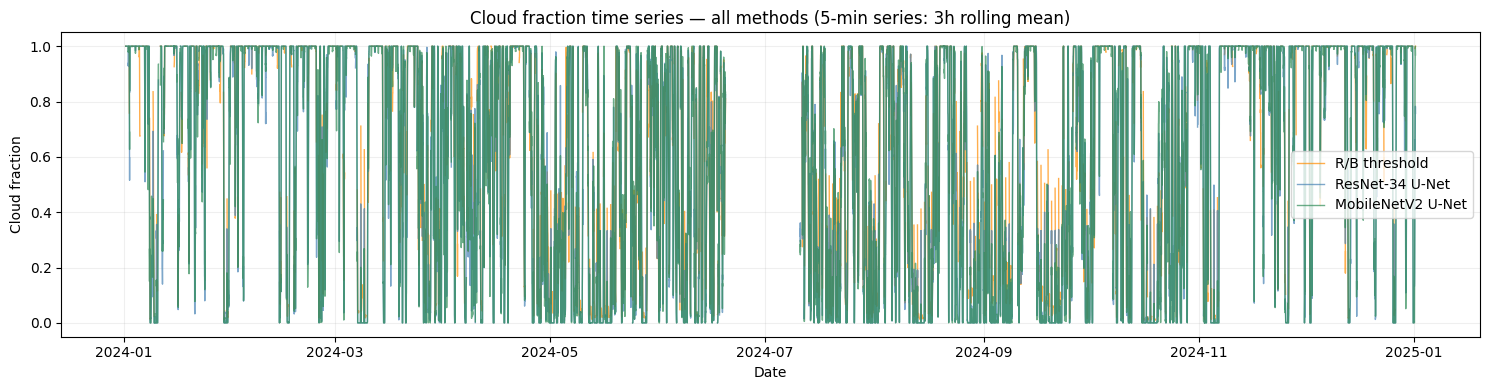

In [5]:
COLOURS = {
    'R/B threshold':    'darkorange',
    'ResNet-34 U-Net':  'steelblue',
    'MobileNetV2 U-Net': 'seagreen',
    'Random Forest':    'purple',
}

fig, ax = plt.subplots(figsize=(15, 4))
for name, df in dfs.items():
    df_s = df.set_index('timestamp').sort_index()
    # Use rolling mean for R/B and CNN (5-min data), raw for VLM (daily)
    if len(df) > 500:
        series = df_s['cloud_fraction'].rolling('3h', min_periods=5).mean()
        lw, alpha = 1.0, 0.7
    else:
        series = df_s['cloud_fraction']
        lw, alpha = 1.5, 0.9
    ax.plot(series.index, series.values, color=COLOURS.get(name,'grey'),
            linewidth=lw, alpha=alpha, label=name)

ax.set_ylabel('Cloud fraction'); ax.set_xlabel('Date')
ax.set_title('Cloud fraction time series — all methods (5-min series: 3h rolling mean)')
ax.set_ylim(-0.05, 1.05); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'comparison_timeseries.png', bbox_inches='tight', dpi=100)
plt.show()

## 5. Monthly breakdown of disagreements

For each month, compute the mean absolute difference between methods.

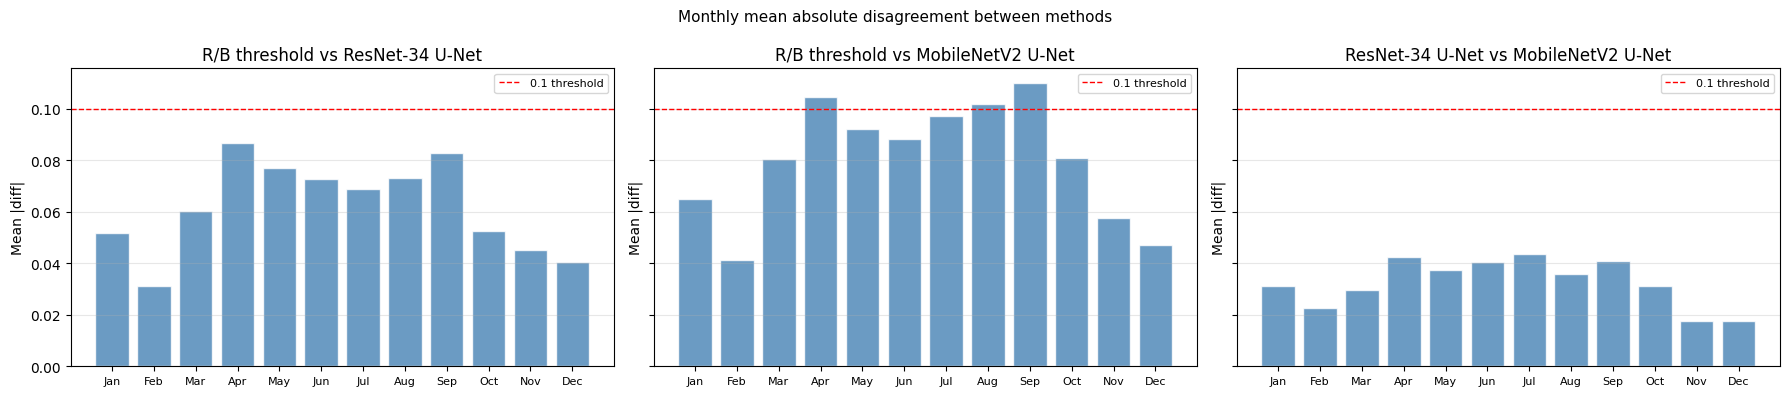

In [6]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

if len(pairs) == 0:
    print('No pairs available.')
else:
    fig, axes = plt.subplots(1, len(pairs), figsize=(6 * len(pairs), 4), sharey=True)
    if len(pairs) == 1:
        axes = [axes]

    for ax, ((na, nb), merged) in zip(axes, pairs.items()):
        if 'month' in merged.columns:
            month_col = 'month'
        elif 'timestamp' in merged.columns:
            merged = merged.copy()
            merged['month'] = pd.to_datetime(merged['timestamp']).dt.month
            month_col = 'month'
        else:
            merged = merged.copy()
            merged['month'] = pd.to_datetime(merged['date']).dt.month
            month_col = 'month'

        merged['abs_diff'] = (merged[na] - merged[nb]).abs()
        monthly_mad = merged.groupby(month_col)['abs_diff'].mean()
        monthly_mad = monthly_mad.reindex(range(1,13), fill_value=np.nan)

        bars = ax.bar(monthly_mad.index, monthly_mad.values,
                      color='steelblue', edgecolor='white', alpha=0.8)
        ax.set_xticks(range(1,13)); ax.set_xticklabels(month_names, fontsize=8)
        ax.set_ylabel('Mean |diff|'); ax.set_title(f'{na} vs {nb}')
        ax.axhline(0.1, color='red', linestyle='--', linewidth=1,
                   label='0.1 threshold'); ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

    fig.suptitle('Monthly mean absolute disagreement between methods', fontsize=11)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'comparison_monthly_disagreement.png', bbox_inches='tight', dpi=100)
    plt.show()

## 6. Flag erroneous images

Find timestamps where **all available methods disagree by > 0.3**.
These are candidates for manual inspection — likely sun glare, lens artifacts,
or transitional conditions where all methods struggle.

In [7]:
DISAGREE_THRESHOLD = 0.3

if len(dfs) < 2:
    print('Need at least 2 methods.')
else:
    # Build a daily mean table across all methods
    daily_tables = []
    for name, df in dfs.items():
        d = df.copy()
        d['date'] = pd.to_datetime(d['timestamp']).dt.date
        daily = d.groupby('date')['cloud_fraction'].mean().rename(name)
        daily_tables.append(daily)

    df_daily = pd.concat(daily_tables, axis=1).dropna()
    method_cols = list(dfs.keys())

    # Max pairwise difference for each day
    df_daily['max_spread'] = df_daily[method_cols].max(axis=1) - df_daily[method_cols].min(axis=1)
    flagged = df_daily[df_daily['max_spread'] > DISAGREE_THRESHOLD].sort_values('max_spread', ascending=False)

    print(f'Days where all methods disagree > {DISAGREE_THRESHOLD}: {len(flagged)}')
    if len(flagged) > 0:
        print(flagged.head(10).to_string(float_format='%.3f'))
        flagged.to_csv(CSV_DIR / 'flagged_disagreements.csv')
        print(f'\nSaved -> {CSV_DIR / "flagged_disagreements.csv"}')

Days where all methods disagree > 0.3: 10
            R/B threshold  ResNet-34 U-Net  MobileNetV2 U-Net  max_spread
date                                                                     
2025-01-01          0.997            0.435              0.479       0.562
2024-10-24          0.835            0.444              0.407       0.427
2024-08-31          0.854            0.470              0.464       0.390
2024-08-24          0.474            0.146              0.089       0.385
2024-03-31          0.949            0.637              0.604       0.345
2024-09-04          0.407            0.096              0.084       0.323
2024-01-16          0.248            0.539              0.565       0.317
2024-04-10          0.961            0.652              0.650       0.311
2024-03-03          0.481            0.788              0.792       0.310
2024-01-21          0.951            0.658              0.643       0.308

Saved -> D:\MOJE\DATA_SCIENCE\SKYCAMERA\skycamera\outputs\csv\flagged

## 7. Evaluation on held-out Warsaw GT test set

**Warsaw test set** — 20% of 627 manual GT masks (random_state=42), never seen during training.
All three methods evaluated: ResNet-34, MobileNetV2, and R/B threshold (daytime images only).

**Metrics:** MAE and Pearson r on cloud fraction; mean IoU on pixel masks (CNN only).
**CF-level breakdown:** error split by clear (<0.2), partial (0.2–0.8), overcast (>0.8).

In [8]:
from skycamera.io import build_combined_dataset
from skycamera.labelling import load_existing_mask, LABEL_CLOUD, LABEL_SKY, LABEL_IGNORE
from skycamera.cnn import load_cnn_model, predict_mask, IMG_SIZE
from skycamera.sun import mask_sun_pixels
import torch, segmentation_models_pytorch as smp, cv2

MANUAL_MASKS = Path('..') / 'data' / 'masks_manual'

df_all    = build_combined_dataset(ACS_ROOT, MANUAL_MASKS)
df_manual = df_all[df_all['source'] == 'manual'].copy()
df_acs    = df_all[df_all['source'] == 'acs_wsi'].copy()

if len(df_manual) >= 5:
    df_manual_trainval, df_test_warsaw = skl_split(df_manual, test_size=0.20, random_state=42)
else:
    df_test_warsaw = df_manual.iloc[0:0]

_, df_test_acs = skl_split(df_acs, test_size=0.20, stratify=df_acs['cf_level'], random_state=42)

print(f'Warsaw test set : {len(df_test_warsaw)} images')
print(f'ACS_WSI test set: {len(df_test_acs)} pairs')

# CF level labels
def cf_level(cf):
    if np.isnan(cf): return 'unknown'
    if cf < 0.2: return 'clear'
    if cf < 0.8: return 'partial'
    return 'overcast'

df_test_warsaw['cf_level_label'] = df_test_warsaw['cf_measured'].apply(cf_level)
print('\nWarsaw test CF distribution:')
print(df_test_warsaw['cf_level_label'].value_counts().to_string())

Combined dataset summary
  ACS_WSI pairs  : 77
  Manual pairs   : 627
  Total          : 704

  CF measured — mean=0.571  std=0.432  min=0.000  max=1.000

  Class balance (by measured CF):
    Clear   (<0.2) : 229  (32.5%)
    Partial (0.2–0.8): 144  (20.5%)
    Cloudy  (>0.8) : 331  (47.0%)
Warsaw test set : 126 images
ACS_WSI test set: 16 pairs

Warsaw test CF distribution:
cf_level_label
overcast    60
clear       40
partial     26


In [9]:
# ── Load models ──────────────────────────────────────────────────────────
warsaw_results = {}   # name -> {MAE, r, IoU, gt, pred, errors_by_level}

rn34_path    = MODEL_DIR / 'cnn_sky.pt'
mobile_path  = MODEL_DIR / 'cnn_mobilenet.pt'
IMG_SIZE_MOBILE = (256, 256)

mean_imgnet = np.array([0.485, 0.456, 0.406], dtype=np.float32)
std_imgnet  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def predict_mobilenet(mobile_model, img, dome_mask, zenith_weights, img_path):
    oh, ow = img.shape[:2]
    r = cv2.resize(img, (IMG_SIZE_MOBILE[1], IMG_SIZE_MOBILE[0]), interpolation=cv2.INTER_LINEAR)
    t = torch.from_numpy(((r.astype(np.float32)/255 - mean_imgnet)/std_imgnet).transpose(2,0,1)).unsqueeze(0)
    with torch.no_grad():
        prob = torch.sigmoid(mobile_model(t)).squeeze().numpy()
    ps = (prob >= 0.5).astype(np.uint8)
    pf = cv2.resize(ps, (ow, oh), interpolation=cv2.INTER_NEAREST)
    pf[~dome_mask] = 0
    active = mask_sun_pixels(dome_mask, img_path)
    cf = weighted_cf(np.where(active, pf, np.uint8(255)), zenith_weights)
    return cf, pf

# ── Evaluate each model ───────────────────────────────────────────────────
def run_eval(predict_fn, df_test, has_pixel_mask=True):
    gt_cfs, pred_cfs, ious, level_errors = [], [], [], []
    for _, row in df_test.iterrows():
        try:
            img_path = Path(row['image_path'])
            img      = load_image(img_path)
            gt_mask  = load_existing_mask(Path(row['mask_path']))
            gt_cf    = weighted_cf(gt_mask, zenith_weights)
            cf_pred, pred_mask = predict_fn(img, img_path)
            if np.isnan(cf_pred): continue
            gt_cfs.append(gt_cf); pred_cfs.append(cf_pred)
            level_errors.append({'gt_cf': gt_cf, 'pred_cf': cf_pred,
                                  'ae': abs(cf_pred - gt_cf),
                                  'level': cf_level(gt_cf)})
            if has_pixel_mask and pred_mask is not None:
                valid  = (gt_mask == LABEL_CLOUD) | (gt_mask == LABEL_SKY)
                gt_bin = (gt_mask == LABEL_CLOUD).astype(np.uint8)
                inter  = (pred_mask & gt_bin & valid).sum()
                union  = ((pred_mask | gt_bin) & valid).sum()
                ious.append(inter / union if union > 0 else 0.0)
        except Exception as e:
            pass
    gt   = np.array(gt_cfs); pred = np.array(pred_cfs)
    ok   = ~np.isnan(gt) & ~np.isnan(pred)
    return {
        'gt': gt, 'pred': pred, 'ok': ok,
        'MAE': float(np.mean(np.abs(pred[ok]-gt[ok]))),
        'r':   float(np.corrcoef(gt[ok], pred[ok])[0,1]) if ok.sum()>2 else float('nan'),
        'IoU': float(np.mean(ious)) if ious else float('nan'),
        'level_df': pd.DataFrame(level_errors),
    }

if len(df_test_warsaw) > 0:
    if rn34_path.exists():
        rn34 = load_cnn_model(rn34_path)
        res = run_eval(
            lambda img, p: predict_mask(rn34, img, dome_mask, IMG_SIZE, weights=zenith_weights, image_path=p),
            df_test_warsaw)
        warsaw_results['ResNet-34'] = res
        print(f'ResNet-34:    MAE={res["MAE"]:.4f}  r={res["r"]:.4f}  IoU={res["IoU"]:.4f}')

    if mobile_path.exists():
        ckpt = torch.load(mobile_path, map_location='cpu')
        mobile = smp.Unet(encoder_name='mobilenet_v2', encoder_weights=None, in_channels=3, classes=1, activation=None)
        mobile.load_state_dict(ckpt['model_state']); mobile.eval()
        res = run_eval(
            lambda img, p: predict_mobilenet(mobile, img, dome_mask, zenith_weights, p),
            df_test_warsaw)
        warsaw_results['MobileNetV2'] = res
        print(f'MobileNetV2:  MAE={res["MAE"]:.4f}  r={res["r"]:.4f}  IoU={res["IoU"]:.4f}')

    # R/B threshold — daytime images only (sun elevation stored in index)
    INDEX_CSV = CSV_DIR / 'image_index.csv'
    if INDEX_CSV.exists():
        df_idx = pd.read_csv(INDEX_CSV, parse_dates=['timestamp'])
        daytime_stems = set(df_idx[df_idx['is_daytime']]['path'].apply(lambda p: Path(p).stem))
    else:
        daytime_stems = None  # fall back to trying all

    RB_THRESHOLD = 0.55
    rb_rows = []
    for _, row in df_test_warsaw.iterrows():
        img_path = Path(row['image_path'])
        if daytime_stems is not None and img_path.stem not in daytime_stems:
            continue
        try:
            img     = load_image(img_path)
            gt_mask = load_existing_mask(Path(row['mask_path']))
            gt_cf   = weighted_cf(gt_mask, zenith_weights)
            active  = mask_sun_pixels(dome_mask, img_path)
            cf_rb, _ = cloud_fraction_rb_threshold(img, active, threshold=RB_THRESHOLD, weights=zenith_weights)
            if np.isnan(cf_rb): continue
            rb_rows.append({'gt_cf': gt_cf, 'pred_cf': cf_rb,
                             'ae': abs(cf_rb - gt_cf), 'level': cf_level(gt_cf)})
        except Exception:
            pass

    if rb_rows:
        rb_df = pd.DataFrame(rb_rows)
        gt_rb   = rb_df['gt_cf'].values
        pred_rb = rb_df['pred_cf'].values
        ok_rb   = ~np.isnan(gt_rb) & ~np.isnan(pred_rb)
        warsaw_results['R/B threshold'] = {
            'gt': gt_rb, 'pred': pred_rb, 'ok': ok_rb,
            'MAE': float(np.mean(np.abs(pred_rb[ok_rb]-gt_rb[ok_rb]))),
            'r':   float(np.corrcoef(gt_rb[ok_rb], pred_rb[ok_rb])[0,1]) if ok_rb.sum()>2 else float('nan'),
            'IoU': float('nan'),
            'level_df': rb_df,
        }
        print(f'R/B thr:      MAE={warsaw_results["R/B threshold"]["MAE"]:.4f}  '
              f'r={warsaw_results["R/B threshold"]["r"]:.4f}  '
              f'n={ok_rb.sum()} (daytime only, thr={RB_THRESHOLD})')

ResNet-34:    MAE=0.0645  r=0.9501  IoU=0.4409
MobileNetV2:  MAE=0.0596  r=0.9516  IoU=0.4322
R/B thr:      MAE=0.1428  r=0.8236  n=103 (daytime only, thr=0.55)


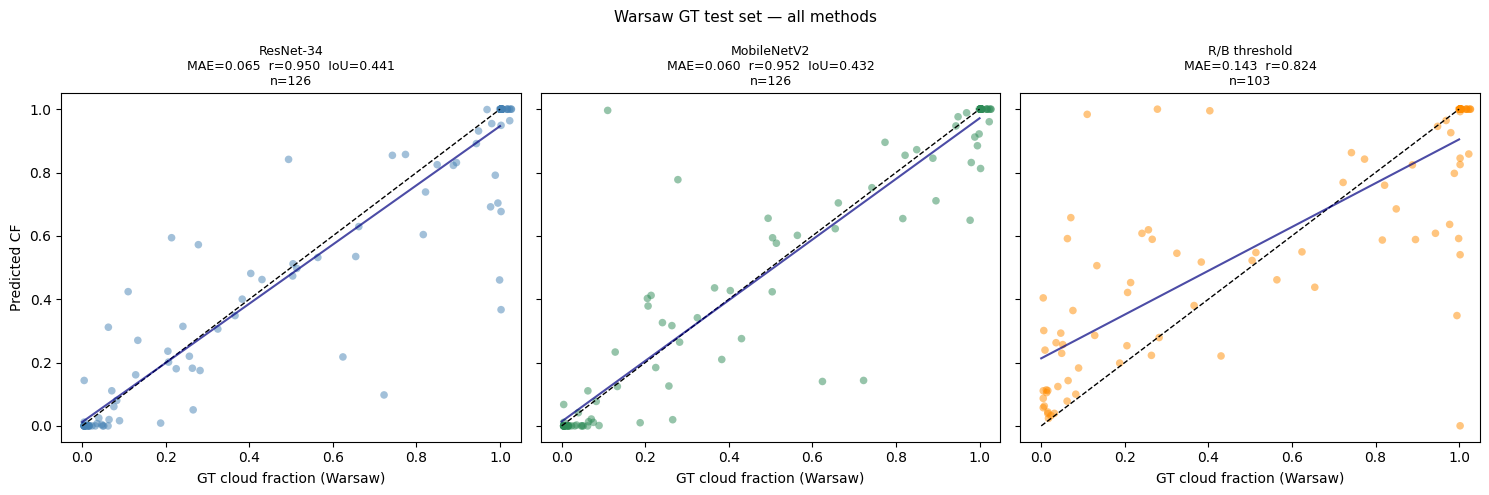

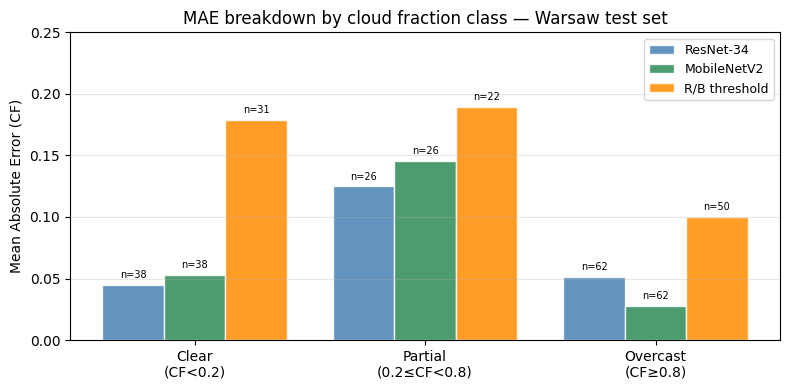

In [10]:
# ── Scatter plots: GT vs predicted CF (one panel per model) ──────────────
n = len(warsaw_results)
COLOURS = {'ResNet-34': 'steelblue', 'MobileNetV2': 'seagreen', 'R/B threshold': 'darkorange'}

if n > 0:
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharey=True)
    if n == 1: axes = [axes]
    for ax, (name, m) in zip(axes, warsaw_results.items()):
        gt, pred, ok = m['gt'], m['pred'], m['ok']
        ax.scatter(gt[ok], pred[ok], alpha=0.5, s=30, color=COLOURS.get(name, 'grey'), edgecolors='none')
        ax.plot([0,1],[0,1],'k--', lw=1)
        slope, intercept, r_val, _, _ = stats.linregress(gt[ok], pred[ok])
        xfit = np.linspace(0,1,100)
        ax.plot(xfit, slope*xfit+intercept, color='navy', lw=1.5, alpha=0.7)
        iou_str = f'  IoU={m["IoU"]:.3f}' if not np.isnan(m['IoU']) else ''
        ax.set_title(f'{name}\nMAE={m["MAE"]:.3f}  r={m["r"]:.3f}{iou_str}\nn={ok.sum()}', fontsize=9)
        ax.set_xlabel('GT cloud fraction (Warsaw)')
        ax.set_ylabel('Predicted CF' if ax == axes[0] else '')
        ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
    fig.suptitle('Warsaw GT test set — all methods', fontsize=11)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'comparison_warsaw_test.png', bbox_inches='tight', dpi=100)
    plt.show()

# ── CF-level breakdown: MAE per clear / partial / overcast ───────────────
level_order = ['clear', 'partial', 'overcast']
level_colors = {'clear': 'gold', 'partial': 'steelblue', 'overcast': 'dimgray'}

if n > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(level_order))
    width = 0.8 / n
    for i, (name, m) in enumerate(warsaw_results.items()):
        ldf = m['level_df']
        maes = [ldf[ldf['level']==lv]['ae'].mean() if (ldf['level']==lv).any() else np.nan
                for lv in level_order]
        ns   = [int((ldf['level']==lv).sum()) for lv in level_order]
        bars = ax.bar(x + i*width - 0.4 + width/2, maes, width,
                      label=name, color=COLOURS.get(name,'grey'), alpha=0.85, edgecolor='white')
        for bar, lv_n, mae in zip(bars, ns, maes):
            if not np.isnan(mae):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                        f'n={lv_n}', ha='center', va='bottom', fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(['Clear\n(CF<0.2)', 'Partial\n(0.2≤CF<0.8)', 'Overcast\n(CF≥0.8)'])
    ax.set_ylabel('Mean Absolute Error (CF)')
    ax.set_title('MAE breakdown by cloud fraction class — Warsaw test set')
    ax.legend(fontsize=9); ax.set_ylim(0, 0.25); ax.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / 'comparison_mae_by_level.png', bbox_inches='tight', dpi=100)
    plt.show()

ACS_WSI test set metrics:
Model                   n    MAE      r
--------------------------------------
R/B threshold          16 0.1427 0.8884
ResNet-34              16 0.0715 0.9028
MobileNetV2            16 0.0735 0.9332


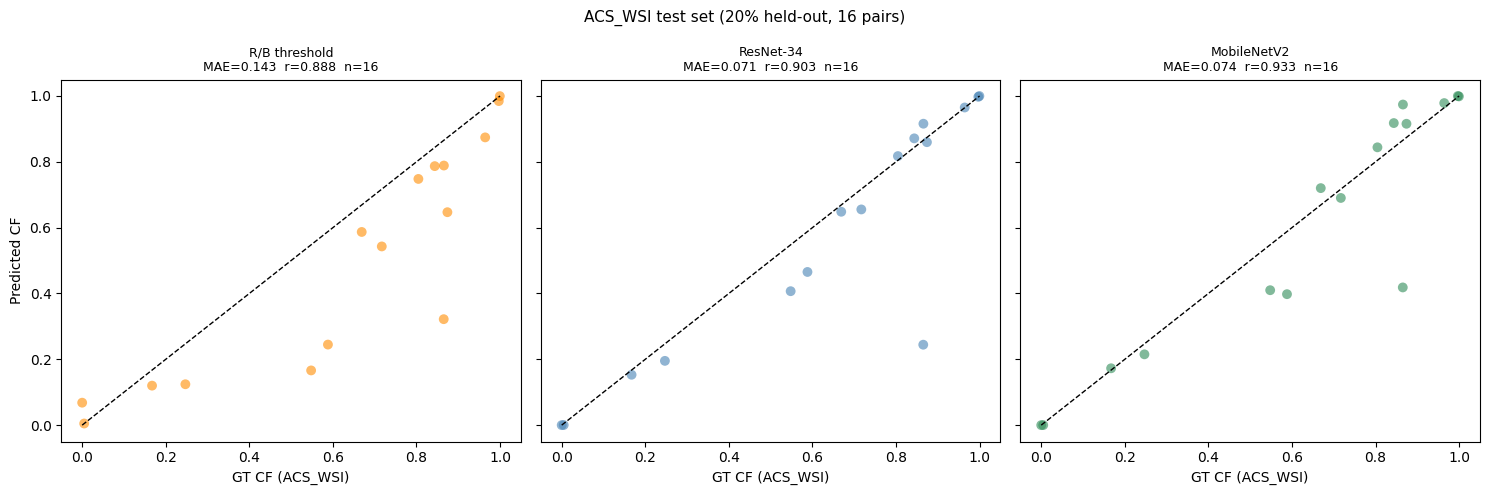

In [11]:
# ── ACS_WSI test set evaluation ──────────────────────────────────────────
gt_cfs, rb_cfs, cnn_cfs, mobile_cfs = [], [], [], []

for _, row in df_test_acs.iterrows():
    img, gt_mask = load_acs_wsi_pair(row['image_path'], row['mask_path'])
    cx_, cy_, r_ = _infer_dome_params(gt_mask)
    w_map    = build_zenith_weight_map(gt_mask.shape[0], gt_mask.shape[1], cx_, cy_, r_, CF_MAX_ZENITH_DEG)
    acs_dome = (gt_mask != 255)
    gt_cf    = weighted_cf(gt_mask, w_map)
    gt_cfs.append(gt_cf)

    rb_cf, _ = cloud_fraction_rb_threshold(img, acs_dome, threshold=0.85, weights=w_map)
    rb_cfs.append(rb_cf)

    try:
        cf_cnn, _ = predict_mask(rn34, img, acs_dome, IMG_SIZE, weights=w_map)
        cnn_cfs.append(cf_cnn)
    except Exception:
        cnn_cfs.append(float('nan'))

    try:
        cf_mob, _ = predict_mobilenet(mobile, img, acs_dome, w_map, Path(row['image_path']))
        mobile_cfs.append(cf_mob)
    except Exception:
        mobile_cfs.append(float('nan'))

gt_arr = np.array(gt_cfs)
acs_preds = {
    'R/B threshold': np.array(rb_cfs),
    'ResNet-34':     np.array(cnn_cfs),
    'MobileNetV2':   np.array(mobile_cfs),
}

print('ACS_WSI test set metrics:')
print(f'{"Model":<20} {"n":>4} {"MAE":>6} {"r":>6}')
print('-' * 38)
acs_results = {}
for name, pred_arr in acs_preds.items():
    ok = ~np.isnan(gt_arr) & ~np.isnan(pred_arr)
    if ok.sum() < 3: continue
    mae = float(np.mean(np.abs(pred_arr[ok] - gt_arr[ok])))
    r   = float(np.corrcoef(gt_arr[ok], pred_arr[ok])[0,1])
    acs_results[name] = (pred_arr, ok, mae, r)
    print(f'{name:<20} {ok.sum():>4} {mae:>6.4f} {r:>6.4f}')

# Scatter — ACS_WSI
fig, axes = plt.subplots(1, len(acs_results), figsize=(5*len(acs_results), 5), sharey=True)
if len(acs_results) == 1: axes = [axes]
for ax, (name, (pred_arr, ok, mae, r)) in zip(axes, acs_results.items()):
    ax.scatter(gt_arr[ok], pred_arr[ok], alpha=0.6, s=50,
               color=COLOURS.get(name, 'grey'), edgecolors='none')
    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(f'{name}\nMAE={mae:.3f}  r={r:.3f}  n={ok.sum()}', fontsize=9)
    ax.set_xlabel('GT CF (ACS_WSI)')
    ax.set_ylabel('Predicted CF' if ax == axes[0] else '')
    ax.set_xlim(-0.05,1.05); ax.set_ylim(-0.05,1.05)
fig.suptitle('ACS_WSI test set (20% held-out, 16 pairs)', fontsize=11)
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'comparison_acs_test.png', bbox_inches='tight', dpi=100)
plt.show()

## 8. Summary table

In [12]:
summary_rows = []

# Warsaw test set
for name, m in warsaw_results.items():
    summary_rows.append({
        'Model': name, 'Test set': 'Warsaw GT',
        'n': int(m['ok'].sum()),
        'MAE': round(m['MAE'],4), 'r': round(m['r'],4),
        'IoU': round(m['IoU'],4) if not np.isnan(m['IoU']) else float('nan'),
    })

# ACS_WSI test set
for name, (pred_arr, ok, mae, r) in acs_results.items():
    summary_rows.append({
        'Model': name, 'Test set': 'ACS_WSI',
        'n': int(ok.sum()), 'MAE': round(mae,4), 'r': round(r,4), 'IoU': float('nan'),
    })

# Pairwise
for _, mrow in df_metrics.iterrows():
    summary_rows.append({
        'Model': f'{mrow["Method A"]} vs {mrow["Method B"]}',
        'Test set': 'Pairwise (full dataset)',
        'n': mrow['n'], 'MAE': mrow['MAE'], 'r': mrow['r'], 'IoU': float('nan'),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(CSV_DIR / 'comparison_summary.csv', index=False)
print('Saved -> comparison_summary.csv\n')
print(df_summary.to_string(index=False))

Saved -> comparison_summary.csv

                               Model                Test set     n    MAE      r    IoU
                           ResNet-34               Warsaw GT   126 0.0645 0.9501 0.4409
                         MobileNetV2               Warsaw GT   126 0.0596 0.9516 0.4322
                       R/B threshold               Warsaw GT   103 0.1428 0.8236    NaN
                       R/B threshold                 ACS_WSI    16 0.1427 0.8884    NaN
                           ResNet-34                 ACS_WSI    16 0.0715 0.9028    NaN
                         MobileNetV2                 ACS_WSI    16 0.0735 0.9332    NaN
    R/B threshold vs ResNet-34 U-Net Pairwise (full dataset)  9276 0.0641 0.9457    NaN
  R/B threshold vs MobileNetV2 U-Net Pairwise (full dataset)  9276 0.0835 0.9189    NaN
ResNet-34 U-Net vs MobileNetV2 U-Net Pairwise (full dataset) 16585 0.0319 0.9755    NaN
